In [1]:

path = "bitcoin-prices-dataset"


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load and Inspect Dataset Structure

In [3]:
dataset_path = path
files = os.listdir(dataset_path)
print(f"Files in dataset: {files}")

csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(dataset_path, csv_file))

print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)

Files in dataset: ['bitcoin.csv']

Dataset shape: (5883, 7)

Column names and types:
Date                 str
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
PriceCategory        str
dtype: object


In [4]:

print(df.head())

         Date  Open      High       Low  Close  Volume PriceCategory
0  2010-01-01   0.3  0.303428  0.295510    0.3   715.8           Low
1  2010-01-02   0.3  0.304377  0.299459    0.3  2028.3           Low
2  2010-01-03   0.3  0.303736  0.295858    0.3   273.0           Low
3  2010-01-04   0.3  0.303406  0.298489    0.3  1452.0           Low
4  2010-01-05   0.3  0.302715  0.296330    0.3  1002.6           Low


## Check for Missing Values

In [5]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per column:
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
PriceCategory    0
dtype: int64

Total missing values: 0


In [6]:
print(df.describe()) # Some  statistics about the dataset

               Open          High           Low         Close        Volume
count   5883.000000   5883.000000   5883.000000   5883.000000  5.883000e+03
mean   21725.051095  21973.716194  21487.576193  21736.779754  1.087915e+08
std    30114.978682  30445.256528  29793.029792  30119.952256  1.851098e+08
min        0.300000      0.300327      0.294003      0.300000  3.030000e+01
25%      430.570000    431.211444    422.134483    430.570000  1.271205e+06
50%     7193.600000   7207.978990   7057.971811   7193.600000  1.756809e+07
75%    42265.190000  42370.135719  41483.578807  42265.190000  1.302297e+08
max    93429.200000  95281.011865  93326.445480  93429.200000  9.325168e+08


## Check for Outliers

In [7]:
# IQR method
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("Outlier Analysis (IQR Method):")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}:")
    print(f"  Number of outliers: {len(outliers)}")

Outlier Analysis (IQR Method):

Open:
  Number of outliers: 0

High:
  Number of outliers: 0

Low:
  Number of outliers: 0

Close:
  Number of outliers: 0

Volume:
  Number of outliers: 687


## Explore Distributions

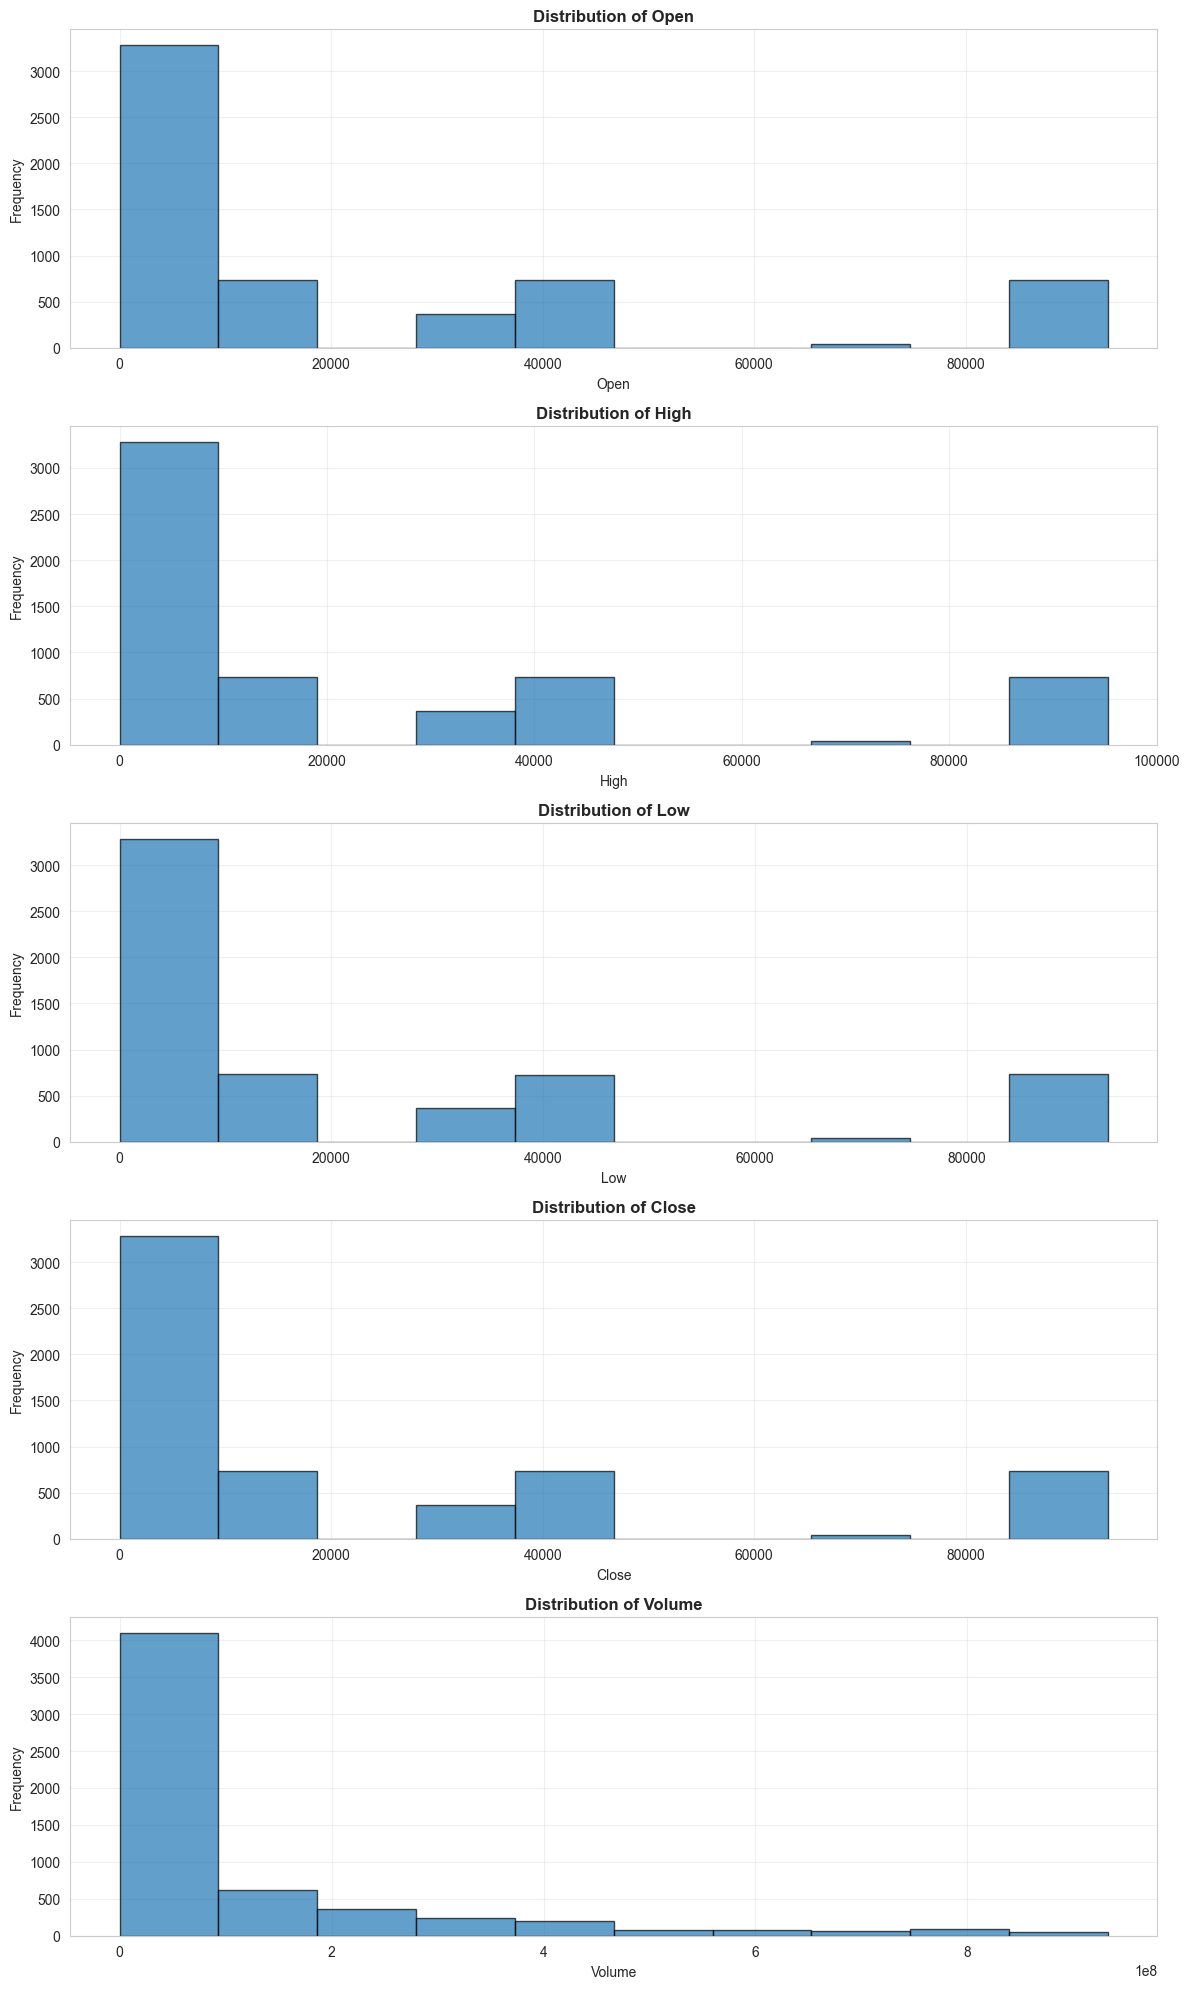

In [8]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 4 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=10, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

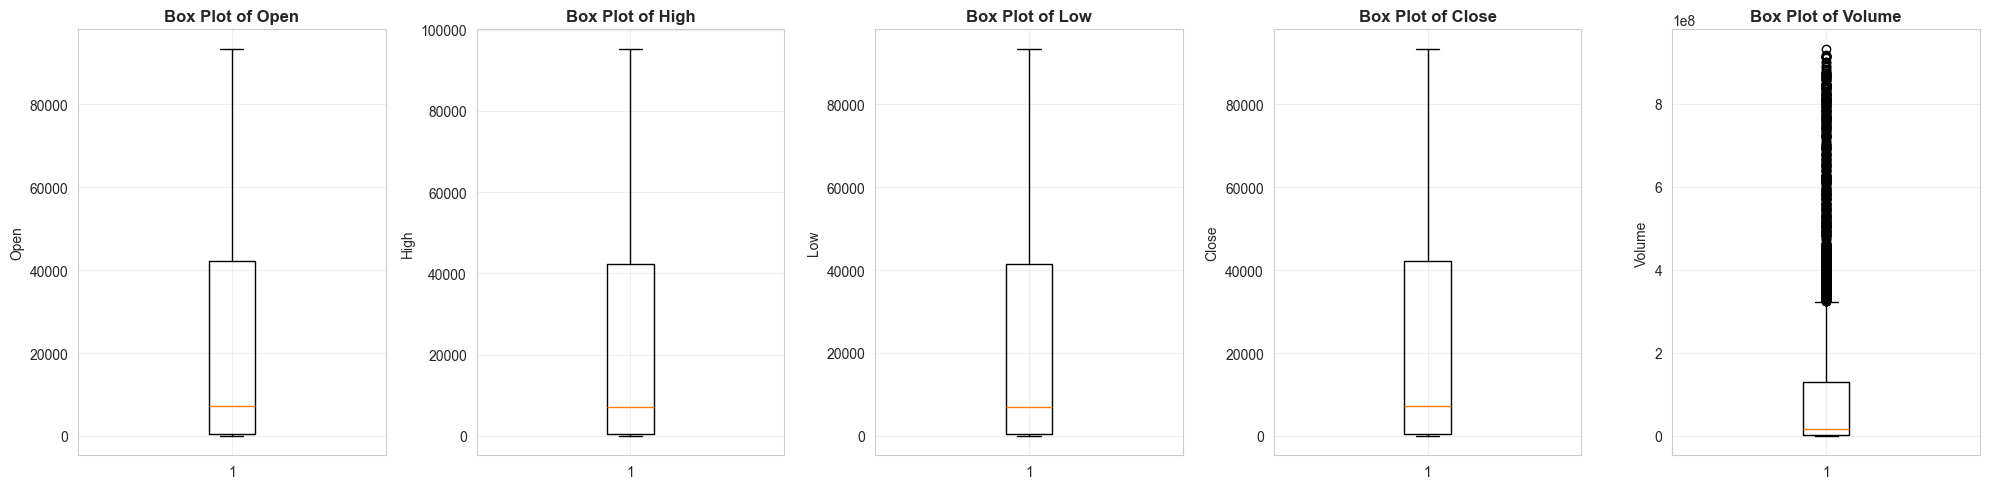

In [9]:

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(4 * len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

# Visualaize outliers with box plots
for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Investigate Relationships Between Variables

Correlation Matrix:
            Open      High       Low     Close    Volume
Open    1.000000  0.999579  0.999846  0.999474  0.808707
High    0.999579  1.000000  0.999428  0.999849  0.808945
Low     0.999846  0.999428  1.000000  0.999582  0.808717
Close   0.999474  0.999849  0.999582  1.000000  0.808891
Volume  0.808707  0.808945  0.808717  0.808891  1.000000


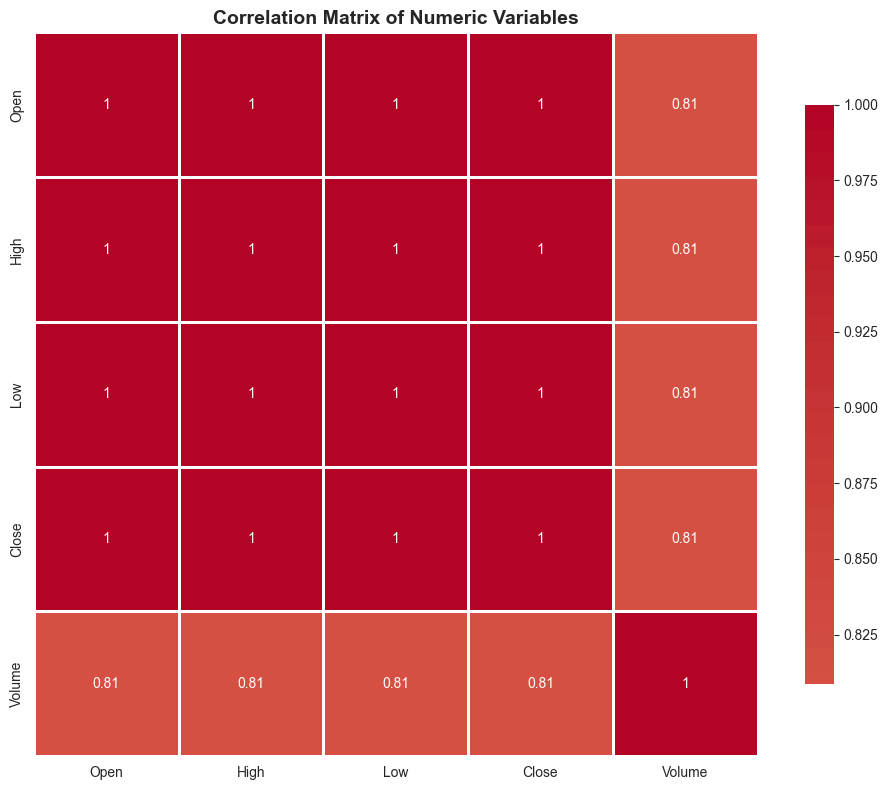

In [10]:
# Correlation matrix
correlation_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

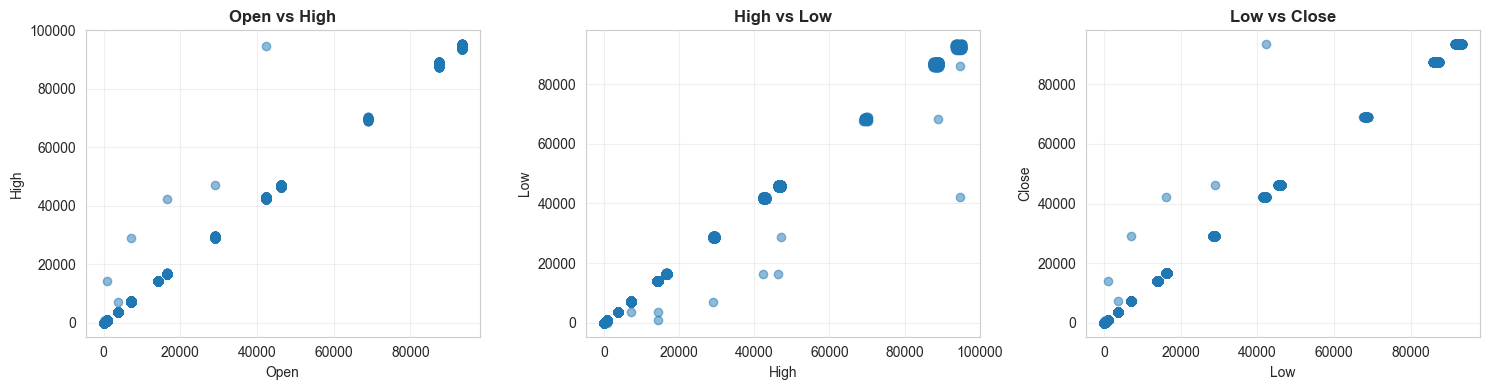

In [11]:
if len(numeric_cols) >= 2:
    fig, axes = plt.subplots(1, min(3, len(numeric_cols) - 1), figsize=(15, 4))
    if len(numeric_cols) - 1 == 1:
        axes = [axes]
    
    for idx in range(min(3, len(numeric_cols) - 1)):
        axes[idx].scatter(df[numeric_cols[idx]], df[numeric_cols[idx + 1]], alpha=0.5)
        axes[idx].set_xlabel(numeric_cols[idx])
        axes[idx].set_ylabel(numeric_cols[idx + 1])
        axes[idx].set_title(f'{numeric_cols[idx]} vs {numeric_cols[idx + 1]}', fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
## Key Insights from the Analysis

- Time Coverage: Data spans from January 2010 to present
- Trading Activity: Variable volume across different market periods
- Strong Correlations: OHLC components are highly correlated

## Recommended Data Visualization Project Directions
1. Multi-Metric Dashboard - Combined price trends, volume, volatility, and categories
2. Price Category Timeline - Color-coded visualization by market phase
3. Comparative Period Analysis - Side-by-side comparison of different market phases